# Source Validation Comparison

In [23]:
#-------imports--------
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
#-------config-----------
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_palette("deep")

RESULT_FILES = {
    "Experiment 1": Path("results/experiment1.json"),
    "Experiment 5": Path("results/experiment5.json"),
}

EXPERIMENT_SETUP = pd.DataFrame(
    [
        {
            "experiment": "Experiment 1",
            "source_validation": "Yes",
            "description": "Full pipeline with SelectorAgent and AdderAgent",
        },
        {
            "experiment": "Experiment 5",
            "source_validation": "No",
            "description": "Top reranked documents passed directly to AnswererAgent",
        },
    ]
)

In [25]:
#----helper functions---------
def load_json(path: Path):
    """Load one JSON result file."""
    if not path.exists():
        print(f"Missing file: {path}")
        return None

    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def safe_pct(delta, base):
    """Compute percentage change safely."""
    if base in (0, None) or pd.isna(base):
        return None
    return 100 * delta / base


def load_summary_results(result_files):
    """Load summary metrics from result JSON files."""
    rows = []

    for experiment, path in result_files.items():
        data = load_json(path)

        if data is None:
            continue

        summary = data.get("summary", {})

        rows.append(
            {
                "experiment": experiment,
                "examples": summary.get("examples"),
                "exact_match": summary.get("exact_match"),
                "f1": summary.get("f1"),
                "retrieval_recall": summary.get("retrieval_recall"),
                "evidence_recall": summary.get("evidence_recall"),
                "avg_runtime": summary.get("avg_runtime"),
                "avg_subquestions": summary.get("avg_subquestions"),
                "avg_selected_docs": summary.get("avg_selected_docs"),
                "avg_retrieved_docs": summary.get("avg_retrieved_docs"),
                "total_runtime": summary.get("total_runtime"),
            }
        )

    return pd.DataFrame(rows)


def find_records(data):
    """Find per-example records in a result JSON file."""
    if data is None:
        return []

    for key in ["records", "results", "examples", "items", "predictions"]:
        value = data.get(key)
        if isinstance(value, list):
            return value

    return []


def load_record_results(result_files):
    """Load per-question records from result JSON files."""
    rows = []

    for experiment, path in result_files.items():
        data = load_json(path)

        if data is None:
            continue

        for i, row in enumerate(find_records(data), start=1):
            if not isinstance(row, dict):
                continue

            rows.append(
                {
                    "question_id": i,
                    "experiment": experiment,
                    "question": row.get("question"),
                    "gold": row.get("gold", row.get("gold_answer", row.get("answer"))),
                    "prediction": row.get("prediction"),
                    "raw_answer": row.get("raw_answer"),
                    "em": row.get("em", row.get("exact_match")),
                    "f1": row.get("f1"),
                    "runtime": row.get("runtime"),
                    "retrieval_recall": row.get("retrieval_recall"),
                    "evidence_recall": row.get("evidence_recall"),
                    "subquestion_count": row.get("subquestion_count"),
                    "selected_count": row.get("selected_count"),
                    "retrieved_count": row.get("retrieved_count"),
                    "selected_titles": row.get("selected_titles"),
                    "retrieved_titles": row.get("retrieved_titles"),
                }
            )

    return pd.DataFrame(rows)


def add_bar_labels(ax, values, label_fmt="{:.3f}", signed=False):
    """Add labels above bars."""
    for patch, value in zip(ax.patches, values):
        if pd.isna(value):
            continue

        vertical_align = "bottom"
        offset = 4

        if signed and value < 0:
            vertical_align = "top"
            offset = -4

        ax.annotate(
            label_fmt.format(value),
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va=vertical_align,
            xytext=(0, offset),
            textcoords="offset points",
            fontsize=9,
        )


def plot_metric(summary_df, metric, title, ylabel, label_fmt="{:.3f}", ylim=None):
    """Plot one summary metric."""
    plot_df = summary_df.dropna(subset=[metric]).copy()

    if plot_df.empty:
        print(f"Skipping {metric}: no values")
        return

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=plot_df,
        x="experiment",
        y=metric,
        hue="experiment",
        dodge=False,
        ax=ax,
    )

    if ax.legend_ is not None:
        ax.legend_.remove()

    add_bar_labels(ax, plot_df[metric], label_fmt=label_fmt)

    ax.set_title(title)
    ax.set_xlabel("Experiment")
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=20, ha="right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        max_value = plot_df[metric].max()
        ax.set_ylim(0, max_value * 1.15 if max_value > 0 else 1)

    plt.tight_layout()
    plt.show()

In [26]:
#-----load data----------
summary_df = load_summary_results(RESULT_FILES)
records_df = load_record_results(RESULT_FILES)

summary_df

,experiment,examples,exact_match,f1,retrieval_recall,evidence_recall,avg_runtime,avg_subquestions,avg_selected_docs,avg_retrieved_docs,total_runtime
0,Experiment 1,50,0.34,0.485045,0.73,0.56,30.969375,2.44,1.64,28.8,1548.507887
1,Experiment 5,50,0.32,0.448651,0.73,0.70,11.847393,2.44,10.00,28.8,592.413887


## 1. Experiment Setup
Overview of the compared source validation configurations.

In [27]:
EXPERIMENT_SETUP

,experiment,source_validation,description
0,Experiment 1,Yes,Full pipeline with SelectorAgent and AdderAgent
1,Experiment 5,No,Top reranked documents passed directly to Answ...


## 2. Main Metrics
Summary of overall QA and retrieval performance metrics.

In [28]:
# main metrics
main_cols = [
    "experiment",
    "examples",
    "exact_match",
    "f1",
    "retrieval_recall",
    "evidence_recall",
    "avg_runtime",
    "avg_subquestions",
    "avg_selected_docs",
    "avg_retrieved_docs",
    "total_runtime",
]

main_table = summary_df[main_cols].copy()

main_table.style.format(
    {
        "exact_match": "{:.3f}",
        "f1": "{:.3f}",
        "retrieval_recall": "{:.3f}",
        "evidence_recall": "{:.3f}",
        "avg_runtime": "{:.2f}s",
        "avg_subquestions": "{:.2f}",
        "avg_selected_docs": "{:.2f}",
        "avg_retrieved_docs": "{:.2f}",
        "total_runtime": "{:.1f}s",
    }
)


,experiment,examples,exact_match,f1,retrieval_recall,evidence_recall,avg_runtime,avg_subquestions,avg_selected_docs,avg_retrieved_docs,total_runtime
0,Experiment 1,50,0.340,0.485,0.730,0.560,30.97s,2.44,1.64,28.80,1548.5s
1,Experiment 5,50,0.320,0.449,0.730,0.700,11.85s,2.44,10.00,28.80,592.4s


## 3. Difference from Baseline
Performance differences between Experiment 5 and the baseline.

In [29]:
# difference from baseline
baseline_name = "Experiment 1"
comparison_name = "Experiment 5"

if baseline_name in summary_df["experiment"].values and comparison_name in summary_df["experiment"].values:
    baseline = summary_df.loc[summary_df["experiment"] == baseline_name].iloc[0]
    experiment5 = summary_df.loc[summary_df["experiment"] == comparison_name].iloc[0]

    delta_metrics = [
        "exact_match",
        "f1",
        "retrieval_recall",
        "evidence_recall",
        "avg_runtime",
        "avg_subquestions",
        "avg_selected_docs",
        "avg_retrieved_docs",
        "total_runtime",
    ]

    delta_rows = []

    for metric in delta_metrics:
        baseline_value = baseline[metric]
        experiment5_value = experiment5[metric]
        absolute_change = experiment5_value - baseline_value

        delta_rows.append(
            {
                "metric": metric,
                "experiment1": baseline_value,
                "experiment5": experiment5_value,
                "absolute_change": absolute_change,
                "relative_change_%": safe_pct(absolute_change, baseline_value),
            }
        )

    delta_df = pd.DataFrame(delta_rows)

else:
    print("Could not compute delta because one or both result files are missing.")
    delta_df = pd.DataFrame()

delta_df.style.format(
    {
        "experiment1": "{:.3f}",
        "experiment5": "{:.3f}",
        "absolute_change": "{:+.3f}",
        "relative_change_%": "{:+.1f}%",
    }
)



,metric,experiment1,experiment5,absolute_change,relative_change_%
0,exact_match,0.340,0.320,-0.020,-5.9%
1,f1,0.485,0.449,-0.036,-7.5%
2,retrieval_recall,0.730,0.730,+0.000,+0.0%
3,evidence_recall,0.560,0.700,+0.140,+25.0%
4,avg_runtime,30.969,11.847,-19.122,-61.7%
5,avg_subquestions,2.440,2.440,+0.000,+0.0%
6,avg_selected_docs,1.640,10.000,+8.360,+509.8%
7,avg_retrieved_docs,28.800,28.800,+0.000,+0.0%
8,total_runtime,1548.508,592.414,-956.094,-61.7%


## 4. Summary Metric Plots
Visual comparison of evaluation metrics across experiments.

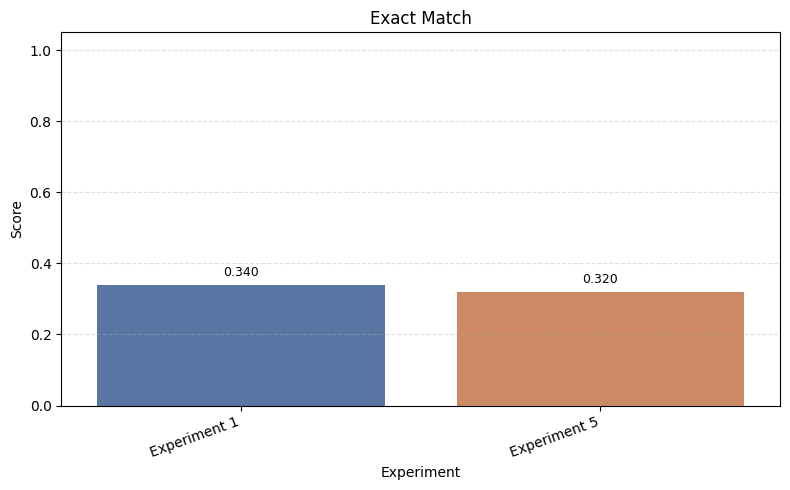

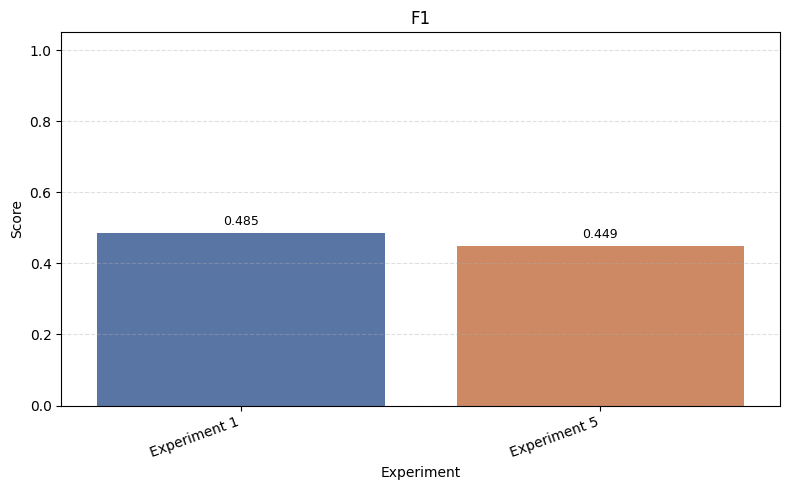

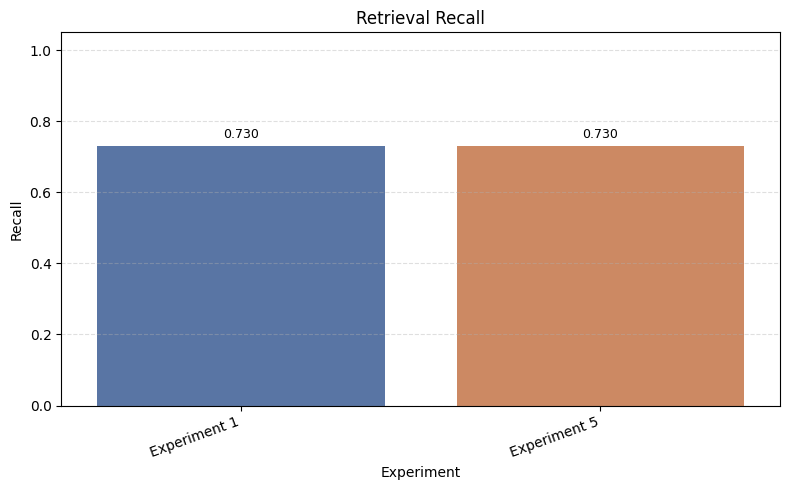

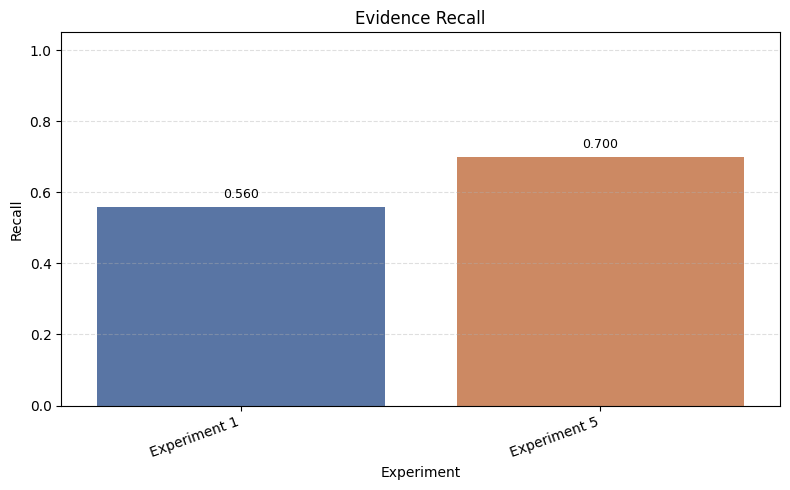

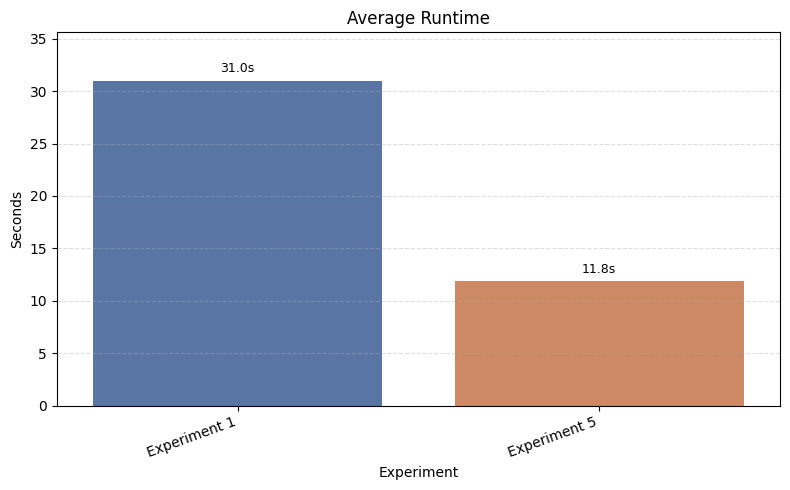

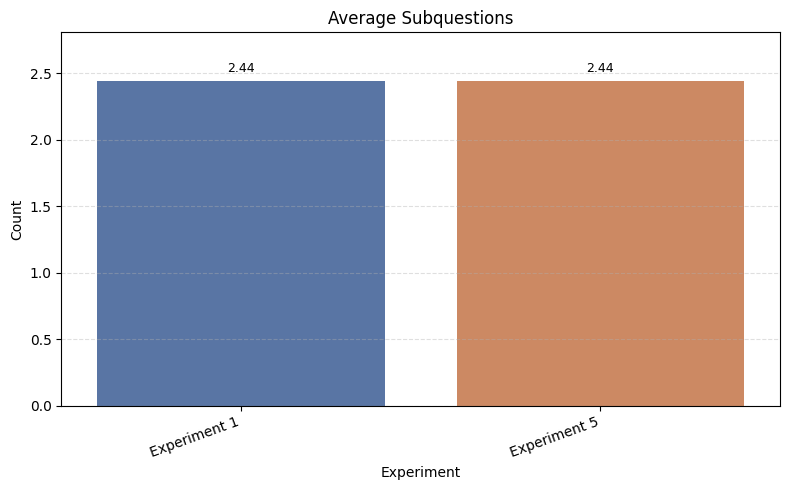

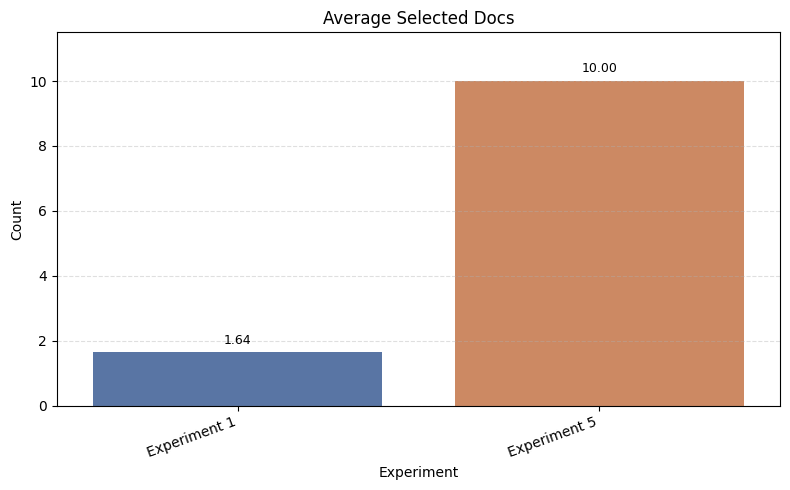

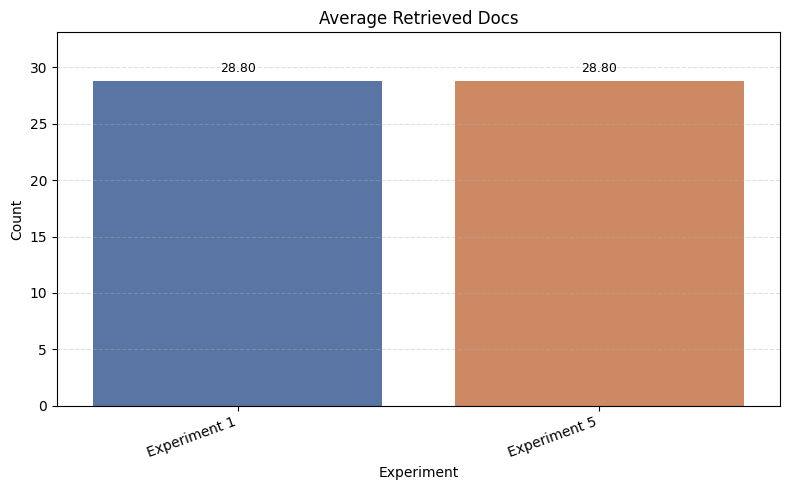

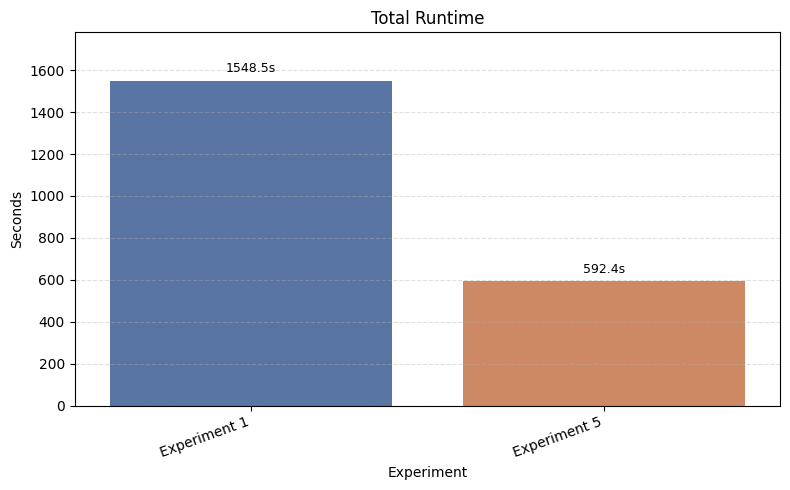

In [30]:
# summary metric plots
metric_specs = [
    ("exact_match", "Exact Match", "Score", "{:.3f}", (0, 1.05)),
    ("f1", "F1", "Score", "{:.3f}", (0, 1.05)),
    ("retrieval_recall", "Retrieval Recall", "Recall", "{:.3f}", (0, 1.05)),
    ("evidence_recall", "Evidence Recall", "Recall", "{:.3f}", (0, 1.05)),
    ("avg_runtime", "Average Runtime", "Seconds", "{:.1f}s", None),
    ("avg_subquestions", "Average Subquestions", "Count", "{:.2f}", None),
    ("avg_selected_docs", "Average Selected Docs", "Count", "{:.2f}", None),
    ("avg_retrieved_docs", "Average Retrieved Docs", "Count", "{:.2f}", None),
    ("total_runtime", "Total Runtime", "Seconds", "{:.1f}s", None),
]

for metric, title, ylabel, label_fmt, ylim in metric_specs:
    if metric in summary_df.columns:
        plot_metric(summary_df, metric, title, ylabel, label_fmt, ylim)


## 5. Recall Metrics Comparison
Comparison of retrieval recall and evidence recall performance.

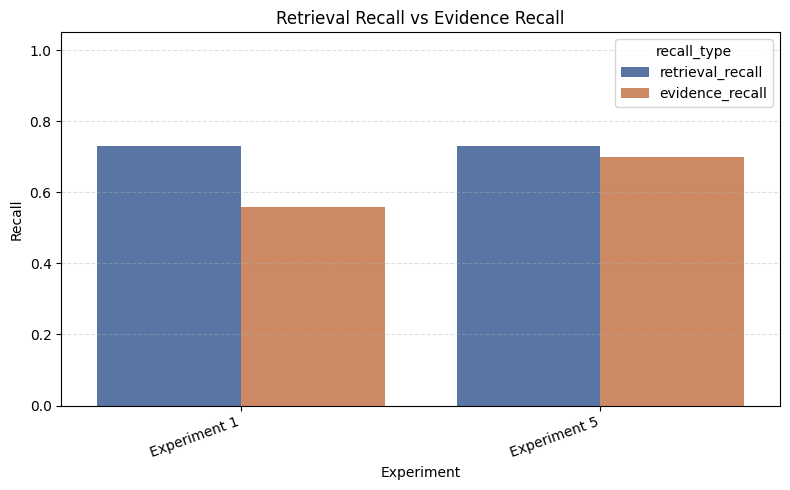

In [31]:
# recall metrics comparison
if {"retrieval_recall", "evidence_recall"}.issubset(summary_df.columns):
    recall_df = summary_df[
        ["experiment", "retrieval_recall", "evidence_recall"]
    ].melt(
        id_vars="experiment",
        var_name="recall_type",
        value_name="recall",
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=recall_df, x="experiment", y="recall", hue="recall_type", ax=ax)

    ax.set_title("Retrieval Recall vs Evidence Recall")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=20, ha="right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()
    

## 6. Automatic Interpretation
Automatic summary of the main experimental findings.

In [32]:
# automatic interpretation
baseline = summary_df.loc[
    summary_df["experiment"] == "Experiment 1"
].iloc[0]

experiment5 = summary_df.loc[
    summary_df["experiment"] == "Experiment 5"
].iloc[0]

print("Baseline: Experiment 1")
print(
    f"- F1 = {baseline['f1']:.3f}, "
    f"EM = {baseline['exact_match']:.3f}, "
    f"avg runtime = {baseline['avg_runtime']:.2f}s"
)
print()

print("Effect of removing source validation (Experiment 5 vs Experiment 1):")
print(f"- F1 delta: {experiment5['f1'] - baseline['f1']:+.3f}")
print(f"- EM delta: {experiment5['exact_match'] - baseline['exact_match']:+.3f}")
print(f"- Retrieval recall delta: {experiment5['retrieval_recall'] - baseline['retrieval_recall']:+.3f}")
print(f"- Evidence recall delta: {experiment5['evidence_recall'] - baseline['evidence_recall']:+.3f}")
print(f"- Runtime delta: {experiment5['avg_runtime'] - baseline['avg_runtime']:+.2f}s")

Baseline: Experiment 1
- F1 = 0.485, EM = 0.340, avg runtime = 30.97s

Effect of removing source validation (Experiment 5 vs Experiment 1):
- F1 delta: -0.036
- EM delta: -0.020
- Retrieval recall delta: +0.000
- Evidence recall delta: +0.140
- Runtime delta: -19.12s


## 7. Error Analysis Candidates
Low-performing examples for qualitative inspection.

In [33]:
# error analysis candidates
if not records_df.empty:
    error_candidates = records_df.sort_values(
        ["f1", "runtime"],
        ascending=[True, False],
    )

    display(
        error_candidates[
            [
                "experiment",
                "question_id",
                "question",
                "gold",
                "prediction",
                "f1",
                "runtime",
                "selected_count",
                "retrieved_count",
            ]
        ].head(20)
    )
else:
    print("records_df is empty")

,experiment,question_id,question,gold,prediction,f1,runtime,selected_count,retrieved_count
29,Experiment 1,30,"What is the name for the adventure in ""Tunnels...",Arena of Khazan,"The adventure in ""Tunnels and Trolls",0.0,50.448538,2,30
0,Experiment 1,1,Were Scott Derrickson and Ed Wood of the same ...,yes,no,0.0,43.645240,2,30
49,Experiment 1,50,Which British first-generation jet-powered med...,English Electric Canberra,The British first-generation jet-powered mediu...,0.0,41.383017,1,30
26,Experiment 1,27,"The 2011–12 VCU Rams men's basketball team, le...",1838,Virginia Commonwealth University was founded i...,0.0,38.100107,2,30
4,Experiment 1,5,"The director of the romantic comedy ""Big Stone...","Greenwich Village, New York City",Not Answerable,0.0,36.965120,2,30
30,Experiment 1,31,"When was Poison's album ""Shut Up, Make Love"" r...",2000,"March 14, 200",0.0,34.575224,2,30
40,Experiment 1,41,Which dog's ancestors include Gordon and Irish...,Scotch Collie,Manchester Terrier,0.0,34.252603,2,30
10,Experiment 1,11,What is the name of the fight song of the univ...,Kansas Song,University of Missouri–Kansas City,0.0,33.190165,2,30
1,Experiment 1,2,What government position was held by the woman...,Chief of Protocol,The woman who portrayed Corliss Archer in the ...,0.0,32.633080,2,30
15,Experiment 1,16,Brown State Fishing Lake is in a country that ...,"9,984",Not Answerable,0.0,31.001642,2,30
